In [1]:
import pandas as pd

band = 'w2'
sub = 8.0
upper = 17.2
var_list = pd.read_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.6_var_table_new.csv'%(sub,upper,band))
print(len(var_list))

7347270


In [87]:
var_list['ra_block'] = [name[0:4] for name in var_list['long_name']]
var_list['dec_block'] = [name[4:8] for name in var_list['long_name']]
print(var_list)

         Unnamed: 0          ra        dec  id_in_matched long_name    id_w1  \
0                 0  100.061060  10.062608         2117.0  0999p106   2130.0   
1                 1   98.577062 -31.874094        24709.0  0988m319  25176.0   
2                 2   99.234759  -5.351004         5684.0  0987m061   5697.0   
3                 3   97.122724  18.210352        42105.0  0967p181  42285.0   
4                 4   95.786774 -34.597409        15569.0  0950m349  15975.0   
...             ...         ...        ...            ...       ...      ...   
7347265         433  257.451545  63.344399        12253.0  2576p636  12447.0   
7347266         434  256.154822  63.275396        25660.0  2576p636  26077.0   
7347267         435  257.692829  51.503958        13005.0  2574p514  13176.0   
7347268         436   68.073382 -80.617730        14590.0  0669m803  14897.0   
7347269         437   61.544490 -74.760277        41035.0  0635m743  41802.0   

           id_w2   distance ra_block de

In [88]:
var_list = var_list.sort_values(by=['ra_block','dec_block'])
print(var_list)

         Unnamed: 0          ra        dec  id_in_matched long_name    id_w1  \
181656        20837    0.345989  -1.621361         5495.0  0000m016   5681.0   
596630        18605  359.641765  -0.922565        12304.0  0000m016  12783.0   
632948        19091  359.556687  -1.990181        14311.0  0000m016  14884.0   
917900        30510    0.378607  -2.194626         9385.0  0000m016   9706.0   
1028497       29641    0.426740  -1.860553         9692.0  0000m016  10024.0   
...             ...         ...        ...            ...       ...      ...   
6447407      115305  358.798736  19.616671        25587.0  3584p196  26487.0   
6447408      115306  358.382780  19.830372        26382.0  3584p196  27311.0   
6447409      115307  358.895896  19.310769        27524.0  3584p196  28510.0   
6447410      115308  358.835229  19.205885        29077.0  3584p196  30112.0   
6752800       75099  358.069979  20.377860        22895.0  3584p196  23703.0   

           id_w2   distance ra_block de

In [62]:
print(len(var_list))

7347270


In [31]:
import numpy as np
n = 10
sliced_var_lists = np.array_split(var_list, n)

In [32]:
print(len(sliced_var_lists[0]))
print(sliced_var_lists[0])

734727
         Unnamed: 0          ra        dec  id_in_matched long_name    id_w1  \
181656        20837    0.345989  -1.621361         5495.0  0000m016   5681.0   
596630        18605  359.641765  -0.922565        12304.0  0000m016  12783.0   
632948        19091  359.556687  -1.990181        14311.0  0000m016  14884.0   
917900        30510    0.378607  -2.194626         9385.0  0000m016   9706.0   
1028497       29641    0.426740  -1.860553         9692.0  0000m016  10024.0   
...             ...         ...        ...            ...       ...      ...   
6969360       67685   60.741994 -77.462277         9501.0  0578m773   9702.0   
6969361       67686   58.451810 -77.015309        14551.0  0578m773  14855.0   
6969362       67687   58.406079 -76.885080        14571.0  0578m773  14875.0   
6969363       67688   55.670207 -77.703296        15005.0  0578m773  15323.0   
6969364       67689   56.991515 -77.691794        17025.0  0578m773  17384.0   

           id_w2   distance ra_b

In [33]:
from util import make_single_light_curve
import numpy as np
from astropy.timeseries import LombScargle
import pickle
import gc

def period_sigma_finding(target_list,index):
    i = 0
    best_period_list = []
    second_period_list = []
    best_fap_list = []
    second_fap_list = []
    sigma2_list = []
    ex_1_sigma2_list = []    
    ex_2_sigma2_list = []
    last_long_name = ''
    table1 = 'placeholder'
    while i < len(target_list):
        long_name = target_list.iloc[i]['long_name']
        id_in_matched = target_list.iloc[i]['id_in_matched']
        name = long_name[0:3]
        if long_name!= last_long_name:
            del table1
            gc.collect()
            table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
        last_long_name = long_name
        ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_in_matched))
        

        mag1 -= np.mean(mag1)
        ls = LombScargle(mjdmean1, mag1)
        freq,power = ls.autopower(minimum_frequency=1/1800, maximum_frequency=1/100)
        best_freq = freq[np.argmax(power)]
        best_period_list.append(1/best_freq)
        best_fap = ls.false_alarm_probability(power.max(),
                                            minimum_frequency=1/1800, maximum_frequency=1/100)
        best_fap_list.append(best_fap)

        power[np.argmax(power)]=-9999999
        second_freq = freq[np.argmax(power)]
        second_period_list.append(1/second_freq)
        second_fap = ls.false_alarm_probability(power.max(), 
                                            minimum_frequency=1/1800, maximum_frequency=1/100)
        second_fap_list.append(second_fap)
        
        # print(1/best_freq, 1/second_freq,best_fap,second_fap,i)
        # print(1/best_freq, 1/second_freq,i)

        sigma2 = np.square(np.std(mag1))
        ex_1_mag = np.array([elmt for j,elmt in enumerate(mag1) if j != np.argmax(mag1)])
        ex_1_sigma2 = np.square(np.std(ex_1_mag))
        ex_2_mag = np.array([elmt for j,elmt in enumerate(ex_1_mag) if j != np.argmin(ex_1_mag)])
        ex_2_sigma2 = np.square(np.std(ex_2_mag))
        sigma2_list.append(sigma2)
        ex_1_sigma2_list.append(ex_1_sigma2)
        ex_2_sigma2_list.append(ex_2_sigma2)

        # print(sigma2,ex_1_sigma2,ex_2_sigma2,i)

        last_counter = int(i/1000)
        i+=1
        if int(i/1000) > last_counter:
            print('%.2f percent done...for pice'%(i/len(target_list)*100),index)

    with open('./tmp_data/w2_period_result%d.pkl'%index, 'wb') as f:
        pickle.dump([best_period_list, best_fap_list, second_period_list, second_fap_list], f)
    with open('./tmp_data/w2_sigma_result%d.pkl'%index, 'wb') as f:
        pickle.dump([sigma2_list, ex_1_sigma2_list, ex_2_sigma2_list], f)
    return 

In [34]:
period_sigma_finding(target_list=var_list,index=0)

0.01 percent done...for pice 0
0.03 percent done...for pice 0
0.04 percent done...for pice 0


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [35]:
from multiprocessing import Pool
thread_pool = Pool()
for i, target_list in enumerate(sliced_var_lists):
    if i < 10:
        thread_pool.apply_async(period_sigma_finding, args=(target_list,i))
thread_pool.close()
thread_pool.join()

0.14 percent done...for pice 6
0.14 percent done...for pice 1
0.14 percent done...for pice 0
0.14 percent done...for pice 7
0.14 percent done...for pice 4
0.27 percent done...for pice 6
0.14 percent done...for pice 2
0.14 percent done...for pice 3
0.14 percent done...for pice 5
0.41 percent done...for pice 6
0.14 percent done...for pice 8
0.54 percent done...for pice 6
0.27 percent done...for pice 1
0.27 percent done...for pice 7
0.27 percent done...for pice 3
0.27 percent done...for pice 8
0.27 percent done...for pice 2
0.14 percent done...for pice 9
0.27 percent done...for pice 0
0.27 percent done...for pice 5
0.27 percent done...for pice 4
0.68 percent done...for pice 6
0.41 percent done...for pice 2
0.41 percent done...for pice 7
0.41 percent done...for pice 1
0.54 percent done...for pice 7
0.41 percent done...for pice 8
0.41 percent done...for pice 0
0.41 percent done...for pice 5
0.68 percent done...for pice 7
0.41 percent done...for pice 3
0.41 percent done...for pice 4


/tmp/ipykernel_4691/2609138642.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')


0.27 percent done...for pice 9
0.54 percent done...for pice 4
0.54 percent done...for pice 8
0.82 percent done...for pice 7
0.54 percent done...for pice 1
0.82 percent done...for pice 6
0.54 percent done...for pice 2
0.68 percent done...for pice 8
0.54 percent done...for pice 3
0.95 percent done...for pice 7
0.54 percent done...for pice 5
0.54 percent done...for pice 0
0.41 percent done...for pice 9
0.68 percent done...for pice 2
0.95 percent done...for pice 6
1.09 percent done...for pice 7
0.82 percent done...for pice 8
0.68 percent done...for pice 1
1.22 percent done...for pice 7
0.68 percent done...for pice 5
0.68 percent done...for pice 4
0.54 percent done...for pice 9
0.95 percent done...for pice 8
0.82 percent done...for pice 2
1.09 percent done...for pice 6
0.68 percent done...for pice 3
0.68 percent done...for pice 9
0.68 percent done...for pice 0
0.82 percent done...for pice 5
1.09 percent done...for pice 8
0.82 percent done...for pice 4
0.82 percent done...for pice 1
1.36 per

/tmp/ipykernel_4691/2609138642.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')


0.82 percent done...for pice 9
0.95 percent done...for pice 5
1.50 percent done...for pice 7
1.22 percent done...for pice 6
1.36 percent done...for pice 8
0.82 percent done...for pice 3
1.63 percent done...for pice 7
1.09 percent done...for pice 5
1.50 percent done...for pice 8
0.82 percent done...for pice 0
0.95 percent done...for pice 4
0.95 percent done...for pice 9
1.77 percent done...for pice 7
1.09 percent done...for pice 2
0.95 percent done...for pice 1
1.63 percent done...for pice 8
1.91 percent done...for pice 7
1.22 percent done...for pice 5
1.77 percent done...for pice 8
2.04 percent done...for pice 7
0.95 percent done...for pice 0
1.36 percent done...for pice 6
1.09 percent done...for pice 9
0.95 percent done...for pice 3
1.09 percent done...for pice 4
2.18 percent done...for pice 7
1.09 percent done...for pice 1
1.22 percent done...for pice 2
1.91 percent done...for pice 8
1.22 percent done...for pice 4
2.04 percent done...for pice 8
1.36 percent done...for pice 5
1.50 per

...

98.27 percent done...for pice 9
98.54 percent done...for pice 3
88.33 percent done...for pice 0
98.68 percent done...for pice 3
98.40 percent done...for pice 9
88.47 percent done...for pice 0
98.54 percent done...for pice 9
98.81 percent done...for pice 3
98.68 percent done...for pice 9
88.60 percent done...for pice 0
98.95 percent done...for pice 3
98.81 percent done...for pice 9
88.74 percent done...for pice 0
98.95 percent done...for pice 9
99.08 percent done...for pice 3
88.88 percent done...for pice 0
99.22 percent done...for pice 3


/tmp/ipykernel_4691/2609138642.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')


99.08 percent done...for pice 9
89.01 percent done...for pice 0
99.36 percent done...for pice 3
99.22 percent done...for pice 9
89.15 percent done...for pice 0
99.49 percent done...for pice 3
99.36 percent done...for pice 9
89.28 percent done...for pice 0
99.63 percent done...for pice 3
99.49 percent done...for pice 9
89.42 percent done...for pice 0
99.76 percent done...for pice 3
89.56 percent done...for pice 0
99.63 percent done...for pice 9
99.90 percent done...for pice 3
89.69 percent done...for pice 0
99.76 percent done...for pice 9
89.83 percent done...for pice 0
89.97 percent done...for pice 0
99.90 percent done...for pice 9
90.10 percent done...for pice 0
90.24 percent done...for pice 0
90.37 percent done...for pice 0
90.51 percent done...for pice 0
90.65 percent done...for pice 0
90.78 percent done...for pice 0
90.92 percent done...for pice 0
91.05 percent done...for pice 0
91.19 percent done...for pice 0
91.33 percent done...for pice 0
91.46 percent done...for pice 0
91.60 pe

/tmp/ipykernel_4691/2609138642.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')


94.05 percent done...for pice 0
94.18 percent done...for pice 0
94.32 percent done...for pice 0
94.46 percent done...for pice 0
94.59 percent done...for pice 0
94.73 percent done...for pice 0
94.87 percent done...for pice 0
95.00 percent done...for pice 0
95.14 percent done...for pice 0
95.27 percent done...for pice 0
95.41 percent done...for pice 0
95.55 percent done...for pice 0
95.68 percent done...for pice 0
95.82 percent done...for pice 0
95.95 percent done...for pice 0
96.09 percent done...for pice 0
96.23 percent done...for pice 0
96.36 percent done...for pice 0
96.50 percent done...for pice 0
96.63 percent done...for pice 0
96.77 percent done...for pice 0
96.91 percent done...for pice 0
97.04 percent done...for pice 0
97.18 percent done...for pice 0
97.32 percent done...for pice 0
97.45 percent done...for pice 0
97.59 percent done...for pice 0
97.72 percent done...for pice 0
97.86 percent done...for pice 0
98.00 percent done...for pice 0
98.13 percent done...for pice 0
98.27 pe

In [1]:
import pickle
best_period_list = []
best_fap_list = []
second_period_list = []
second_fap_list = []
sigma2_list = []
ex_1_sigma2_list = []
ex_2_sigma2_list = []

for i in range(0,10):
    best_period_list_i, best_fap_list_i, second_period_list_i, second_fap_list_i = pickle.load(open('./tmp_data/period_result%d.pkl'%i, "rb"))
    # best_period_list_i, best_fap_list_i, second_period_list_i, second_fap_list_i = pickle.load(open('./tmp_data/w2_period_result%d.pkl'%i, "rb"))
    best_period_list+=best_period_list_i
    best_fap_list+=best_fap_list_i
    second_period_list+=second_period_list_i
    second_fap_list+=second_fap_list_i
    # sigma2_list_i, ex_1_sigma2_list_i, ex_2_sigma2_list_i = pickle.load(open('./tmp_data/sigma_result%d.pkl'%i, "rb"))
    # sigma2_list_i, ex_1_sigma2_list_i, ex_2_sigma2_list_i = pickle.load(open('./tmp_data/w2_sigma_result%d.pkl'%i, "rb"))
    # sigma2_list+=sigma2_list_i
    # ex_1_sigma2_list+=ex_1_sigma2_list_i
    # ex_2_sigma2_list+=ex_2_sigma2_list_i

In [2]:
len(best_period_list)

8619532

In [3]:
import pandas as pd
band = 'w1'
sub = 8.0
# upper = 17.2
upper=18.3
var_list = pd.read_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.6_var_table_new.csv'%(sub,upper,band))
print(len(var_list))

8619532


In [4]:
var_list['best_period'] = best_period_list
var_list.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.6_var_table_new.csv'%(sub,upper,band),index=False)

In [12]:
import numpy as np
var_list['best_period'] = best_period_list
var_list['ex1_sigma_ratio'] = np.divide(sigma2_list,ex_1_sigma2_list)
var_list['ex2_sigma_ratio'] = np.divide(sigma2_list,ex_2_sigma2_list)

In [56]:
var_list.columns

Index(['Unnamed: 0', 'ra', 'dec', 'id_in_matched', 'long_name', 'id_w1',
       'id_w2', 'distance', 'best_period', 'ex1_sigma_ratio',
       'ex2_sigma_ratio'],
      dtype='object')

In [13]:
example_list1 = var_list[(var_list['best_period']>360) & (var_list['best_period']<370)]
example_list2 = var_list[var_list['ex1_sigma_ratio']>100]
example_list3 = var_list[(var_list['ex1_sigma_ratio'] <10) & (var_list['ex2_sigma_ratio'] >10)]

In [135]:
len(example_list1)

166946

70013
98.0892726 , 5.2267916 98.0892726 5.2267916
1.3726500511288195


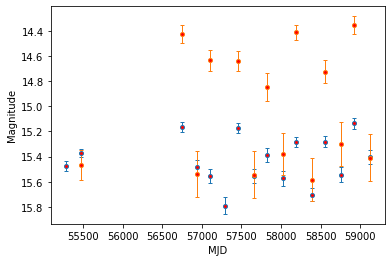

In [139]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from util import make_single_light_curve
i = 70000
target_list = example_list1
while i < len(target_list):
    clear_output(wait=True)
    # ra,dec = target_list.iloc[i]['ra'],target_list.iloc[i]['dec']
    # print(ra,dec)
    long_name = target_list.iloc[i]['long_name']
    id_in_matched = target_list.iloc[i]['id_in_matched']
    id_w1 = target_list.iloc[i]['id_w1']
    id_w2 = target_list.iloc[i]['id_w2']
    name = long_name[0:3]
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))

    print(i)
    print(ra1,',',dec1,ra2,dec2)
    print(target_list.iloc[i]['ex1_sigma_ratio'])
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.invert_yaxis()
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.errorbar(mjdmean2,mag2,error2,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.show()
    user_input = input('Do you want to continue? (y/n)')

    if user_input == 'n':
        break
    i+=1

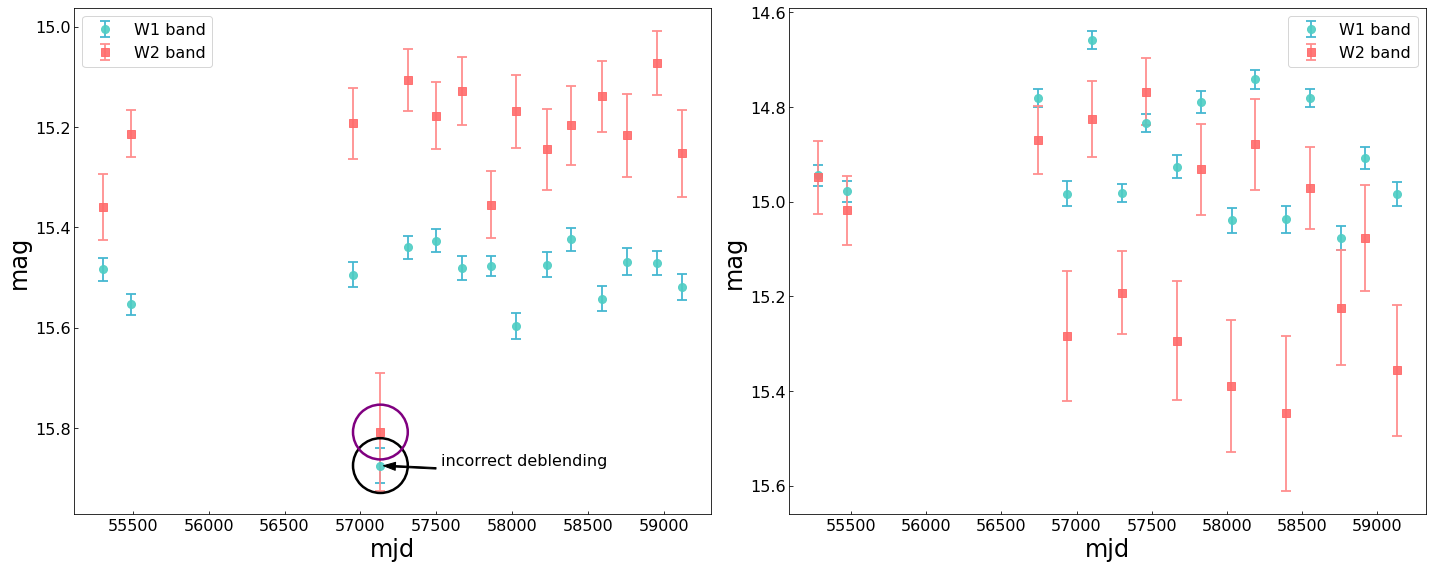

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate
from util import make_single_light_curve


# 创建图形
plt.figure(figsize=(20, 8))
plt.style.use('seaborn-pastel')

plt.subplot(1, 2, 1)
target_list = example_list2
i=304
long_name = target_list.iloc[i]['long_name']
id_in_matched = target_list.iloc[i]['id_in_matched']
id_w1 = target_list.iloc[i]['id_w1']
id_w2 = target_list.iloc[i]['id_w2']
name = long_name[0:3]
table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))

# time = mjdmean1
# magnitude = mag1
# error = error1

# 您的数据 - 替换为实际数据
# 波段1数据
time_b = mjdmean1
magnitude_b = mag1
error_b = error1

# 波段2数据
time_v = mjdmean2
magnitude_v = mag2
error_v = error2




# 绘制波段1的带误差棒的数据点
plt.errorbar(time_b, magnitude_b, yerr=error_b, fmt='o', color='#4ECDC4', 
             ecolor='#45B7D1', elinewidth=2, capsize=5, capthick=2,
             markersize=8, label='W1 band', alpha=0.9)

# 绘制波段2的带误差棒的数据点
plt.errorbar(time_v, magnitude_v, yerr=error_v, fmt='s', color='#FF6B6B', 
             ecolor='#FF8E8E', elinewidth=2, capsize=5, capthick=2,
             markersize=8, label='W2 band', alpha=0.9)

# 添加图例
plt.legend(fontsize=16, loc='best')


# 圈出特定的数据点
highlight_index_b = 3  
highlight_index_v = 3  

# 圈出波段1的特定点
plt.scatter(time_b[highlight_index_b], magnitude_b[highlight_index_b], 
           s=3000, facecolors='none', edgecolors='black', linewidths=2.5, 
           zorder=10, label='')

# 圈出波段2的特定点
plt.scatter(time_v[highlight_index_v], magnitude_v[highlight_index_v], 
           s=3000, facecolors='none', edgecolors='purple', linewidths=2.5, 
           zorder=10, label='')

# 添加注释
plt.annotate('incorrect deblending', 
             xy=(time_b[highlight_index_b], magnitude_b[highlight_index_b]), 
             xytext=(time_b[highlight_index_b] + 400, magnitude_b[highlight_index_b] ),  # 文本在数据点右侧
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=16, ha='left')  # 文本左对齐

# 添加标题和标签
# plt.title('example light curve with artifict a', fontsize=30,  pad=20)
plt.xlabel('mjd', fontsize=24)
plt.ylabel('mag', fontsize=24)
plt.tick_params(labelsize=16,axis='both',direction='in')


# 反转Y轴（天文学中星等值越小表示越亮）
plt.gca().invert_yaxis()

# # 添加网格
# plt.grid(True, linestyle='--', alpha=0.7)


# 美化坐标轴
# sns.despine()

# 调整布局
plt.tight_layout()

plt.subplot(1,2,2)

target_list = example_list1
i=70002
long_name = target_list.iloc[i]['long_name']
id_in_matched = target_list.iloc[i]['id_in_matched']
id_w1 = target_list.iloc[i]['id_w1']
id_w2 = target_list.iloc[i]['id_w2']
name = long_name[0:3]
table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))

time = mjdmean1
magnitude = mag1
error = error1

# 您的数据 - 替换为实际数据
# 波段1数据
time_b = mjdmean1
magnitude_b = mag1
error_b = error1

# 波段2数据
time_v = mjdmean2
magnitude_v = mag2
error_v = error2




# 绘制波段1的带误差棒的数据点
plt.errorbar(time_b, magnitude_b, yerr=error_b, fmt='o', color='#4ECDC4', 
             ecolor='#45B7D1', elinewidth=2, capsize=5, capthick=2,
             markersize=8, label='W1 band', alpha=0.9)

# 绘制波段2的带误差棒的数据点
plt.errorbar(time_v, magnitude_v, yerr=error_v, fmt='s', color='#FF6B6B', 
             ecolor='#FF8E8E', elinewidth=2, capsize=5, capthick=2,
             markersize=8, label='W2 band', alpha=0.9)

# 添加图例
plt.legend(fontsize=16, loc='best')


# 添加标题和标签
# plt.title('example light curve with artifict b', fontsize=18,  pad=20)
plt.xlabel('mjd', fontsize=24)
plt.ylabel('mag', fontsize=24)
plt.tick_params(labelsize=16,axis='both',direction='in')

# 反转Y轴（天文学中星等值越小表示越亮）
plt.gca().invert_yaxis()


# 美化坐标轴
# sns.despine()

# 调整布局
plt.tight_layout()

plt.savefig('./figs/articicial light curve.svg', format='svg')
# 显示图形
plt.show()

26/70002/70005/700013   51/61/304

In [52]:
len(best_period_list)

7347270

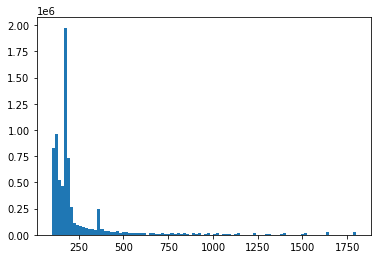

In [4]:
from matplotlib import pyplot as plt
plt.hist(best_period_list,bins=100)
plt.show()

In [15]:
effective_best_period_list = [period for i, period in enumerate(best_period_list) if best_fap_list[i]<0.05]
print(len(effective_best_period_list))
effective_second_period_list = [period for i, period in enumerate(second_period_list) if second_fap_list[i]<0.05]
print(len(effective_second_period_list))

941911
714529


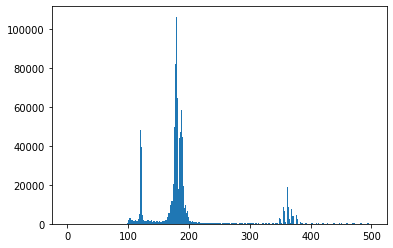

In [8]:
plt.hist(effective_best_period_list,bins=300,range =(0,500))
plt.show()
# plt.hist(effective_best_period_list,bins=100,range =(100,230))
# plt.show()
# plt.hist(effective_second_period_list,bins=100,range =(0,500))
# plt.show()

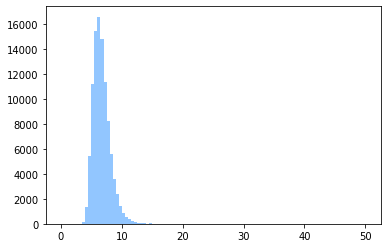

In [30]:
import numpy as np
ratiolist1 = []
for i in range(0,100000):
    t = np.linspace(0,16,16)
    base_signal = 0.00001 * np.sin(2 * np.pi * t/16)
    y1 = base_signal + np.random.normal(0,0.02,len(t))
    # y2 = base_signal + 1 + np.random.normal(0,0.05,len(t))

    y1[3]+=0.5
    # y1[7]+=0.5


    ratiolist1.append( np.std(y1) / np.std([mag for i, mag in enumerate(y1) if i!=3])) 
    # ratiolist1.append( np.std(y1) / np.std([mag for i, mag in enumerate(y1) if (i!=3)and (i!=7)])) 

plt.hist(ratiolist1,bins=100,range=(0,50))
plt.show()

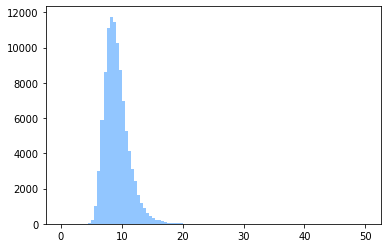

In [31]:
import numpy as np
ratiolist2 = []
for i in range(0,100000):
    t = np.linspace(0,16,16)
    base_signal = 0.00001 * np.sin(2 * np.pi * t/16)
    y1 = base_signal + np.random.normal(0,0.02,len(t))
    # y2 = base_signal + 1 + np.random.normal(0,0.05,len(t))

    y1[3]+=0.5
    y1[7]+=0.5


    ratiolist2.append( np.std(y1) / np.std([mag for i, mag in enumerate(y1) if (i!=3)and (i!=7)])) 

plt.hist(ratiolist2,bins=100,range=(0,50))
plt.show()

In [100]:
# ratiolist1 = ratiolist
# ratiolist2 = ratiolist

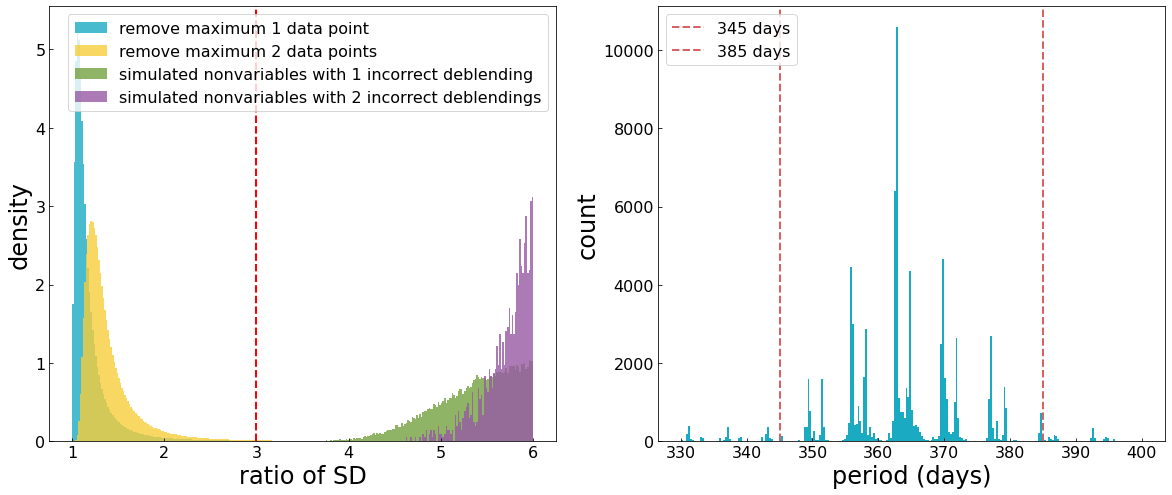

In [32]:
from matplotlib import pyplot as plt
import numpy as np
plt.style.use('seaborn-pastel')

plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
plt.hist(np.sqrt(np.divide(sigma2_list,ex_1_sigma2_list)),density=True,bins=300,range=(1,6),alpha=0.8,color='#1AAAC2',label='remove maximum 1 data point')
plt.hist(np.sqrt(np.divide(sigma2_list,ex_2_sigma2_list)),density=True,bins=300,range=(1,6),alpha=0.8,color='#F7CD3B',label='remove maximum 2 data points')
plt.hist((ratiolist1),density=True,bins=300,range=(1,6),alpha=0.8,color='#75A140',label='simulated nonvariables with 1 incorrect deblending')
plt.hist((ratiolist2),density=True,bins=300,range=(1,6),alpha=0.8,color='#975AA4',label='simulated nonvariables with 2 incorrect deblendings')
# plt.title('distribution of ratio of SD before and after remove maximum datapoint',fontsize=16, pad=20)
plt.xlabel('ratio of SD',fontsize=24)
plt.ylabel('density',fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=16,direction='in')
plt.legend(fontsize=16, loc='upper right')
plt.axvline(x=3,color='red',linestyle='--',linewidth=2,label='ratio=3')


plt.subplot(1,2,2)
plt.hist(effective_best_period_list,bins=240,range=(330,400),color='#1AAAC2')
# plt.title('distribution of lomb-scargle best period around 365 days',fontsize=16, pad=20)
plt.xlabel('period (days)',fontsize=24)
plt.ylabel('count',fontsize=24)
plt.xticks(fontsize=16)
plt.axvline(x=345, color='#D96161', linestyle='--', linewidth=2, label='345 days')
plt.axvline(x=385, color='#D96161', linestyle='--', linewidth=2, label='385 days')
plt.tick_params(axis='both', which='major', labelsize=16,direction='in')
plt.legend(fontsize=16, loc='upper left')
plt.savefig('./figs/filtering.svg',format='svg')

plt.show()


In [40]:
# plt.hist(effective_second_period_list,bins=100,range=(345,385))
# plt.show()

In [69]:
best_period_exclude_list = [i for i,period in enumerate(best_period_list)
                            if best_fap_list[i]<0.05 and period>345 and period<385]
second_period_exclude_list = [i for i,period in enumerate(second_period_list)
                             if second_fap_list[i]<0.05 and period>345 and period<385]


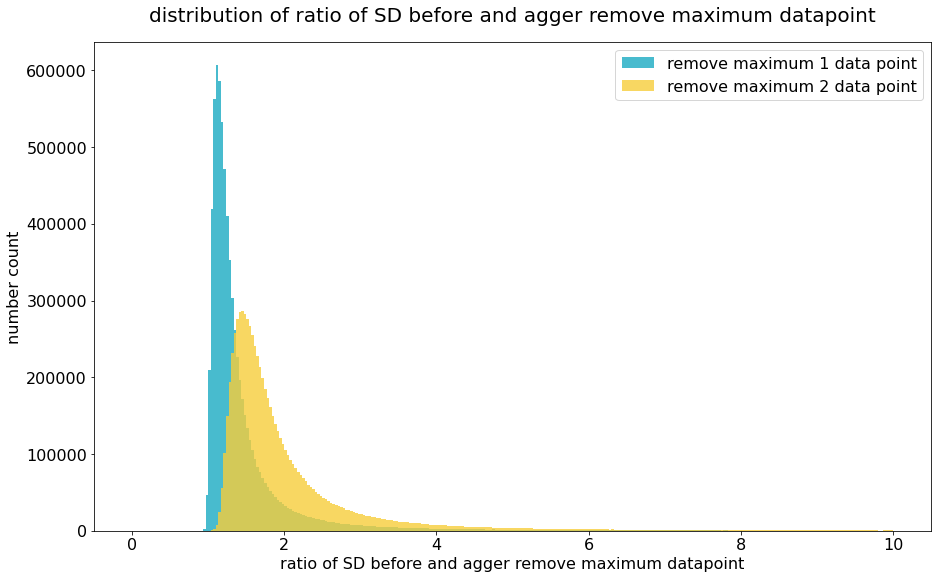

In [36]:
from matplotlib import pyplot as plt
import numpy as np
plt.figure(figsize=(15,9))
plt.hist(np.divide(sigma2_list,ex_1_sigma2_list),bins=300,range=(0,10),alpha=0.8,color='#1AAAC2',label='remove maximum 1 data point')
plt.hist(np.divide(sigma2_list,ex_2_sigma2_list),bins=300,range=(0,10),alpha=0.8,color='#F7CD3B',label='remove maximum 2 data point')
plt.title('distribution of ratio of SD before and agger remove maximum datapoint',fontsize=20, pad=20)
plt.xlabel('ratio of SD before and agger remove maximum datapoint',fontsize=16)
plt.ylabel('number count',fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(fontsize=16, loc='upper right')
plt.show()

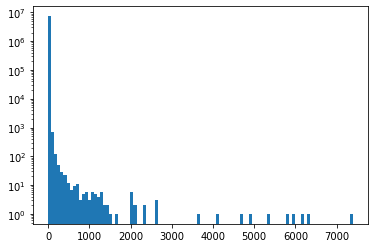

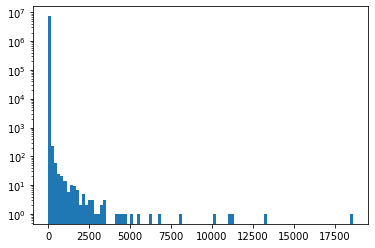

In [19]:
from matplotlib import pyplot as plt
plt.hist(np.divide(sigma2_list,ex_1_sigma2_list),bins=100,log=True)
plt.show()
plt.hist(np.divide(sigma2_list,ex_2_sigma2_list),bins=100,log=True)
plt.show()

In [73]:
ex1 = np.divide(sigma2_list,ex_1_sigma2_list)
ex2 = np.divide(sigma2_list,ex_2_sigma2_list)
sigma2_excluded_list = [i for i,simga2 in enumerate(sigma2_list) if (ex1[i]>10 or ex2[i]>10)]
print(len(sigma2_excluded_list))

66466


In [27]:
import numpy as np
from matplotlib import pyplot as plt    

result_list = []
for i in range(0,10000):
    t = np.linspace(0,16,16)
    base_signal = 1.00001 * np.sin(2 * np.pi * t/16)
    # base_signal = t*0.125
    y = base_signal + np.random.normal(0,0.1,len(t))
    j = np.random.randint(0,len(t))
    y[j]+=1.75
    sigma2 = np.square(np.std(y))
    ex_1_mag = np.array([elmt for j,elmt in enumerate(y) if j != np.argmax(y)])
    ex_1_sigma2 = np.square(np.std(ex_1_mag))
    result_list.append(sigma2/ex_1_sigma2)
    

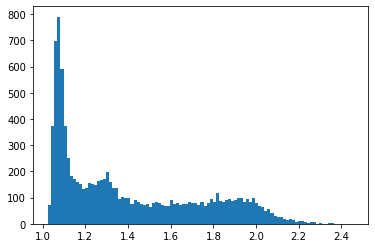

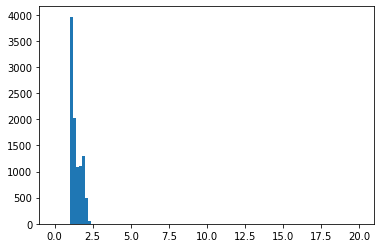

In [17]:
plt.hist(result_list,bins=100)
plt.show()
plt.hist(result_list,bins=100,range=(0,20))
plt.show()

In [89]:
corelation_list = []
mean_list = []
i=0
last_long_name = '' 
while i < len(var_list):
    long_name = var_list.iloc[i]['long_name']
    id_in_matched = var_list.iloc[i]['id_in_matched']
    id_w1 = var_list.iloc[i]['id_w1']
    id_w2 = var_list.iloc[i]['id_w2']
    name = long_name[0:3]
    if long_name!= last_long_name:
        tc = pd.read_csv('/data/project_unTimely_light_curve/mached_catalog/'+name+'/'+long_name+'/'+long_name+'_'+band+'_corelation_with_Mean.csv')
    last_long_name = long_name
    line = tc.loc[(tc['id_w1']==id_w1) & (tc['id_w2']==id_w2)]
    corelation_list.append(float(line['corelation']))
    mean_list.append(float(line['Mean']))
    # print(line['corelation'],line['Mean'],i)
    if i%1000==0:
        print(float(line['corelation']),float(line['Mean']),i)  
    i+=1

0.7719286683335461 8.638111387504138 0
0.6429302774310641 15.924278821243158 1000
0.7553521569957925 14.627746999731215 2000
0.6249887242034771 15.251436254046473 3000
0.6869930208727454 16.376852707225737 4000
0.9407853529349464 16.390152207410264 5000
0.8001667646568501 15.005044373883166 6000
0.6289246685100603 9.738716394004646 7000
0.6786082367961714 16.31837365444343 8000
0.637786331272804 16.680052349393762 9000
0.721685781606526 16.480740172685433 10000
0.6558125902073246 15.887615635624291 11000
0.6911026987191233 13.750655322123311 12000
0.6865432498468768 15.814899487576122 13000
0.6212528556615862 15.9380834514766 14000
0.9103007101274057 16.375203493576713 15000
0.6344196581208396 15.16820220528612 16000
0.6420067645530997 16.049984981184057 17000
0.6953254603629684 11.362772862681172 18000
0.7065726141202731 16.154649138999083 19000
0.6341458412746509 16.063827262385022 20000
0.9311616675417944 13.860827048645486 21000
0.926022447324866 10.64807169965741 22000
0.938201895

In [81]:
import pickle
with open('./tmp_data/var_corelation.pkl', 'wb') as f:
    pickle.dump(corelation_list, f)
with open('./tmp_data/var_mean.pkl', 'wb') as f:
    pickle.dump(mean_list, f)

In [90]:
import pickle
with open('./tmp_data/w2_var_corelation.pkl', 'wb') as f:
    pickle.dump(corelation_list, f)
with open('./tmp_data/w2_var_mean.pkl', 'wb') as f:
    pickle.dump(mean_list, f)

In [83]:
import pickle
corelation_list = pickle.load(open('./tmp_data/var_corelation.pkl', 'rb'))
mean_list = pickle.load(open('./tmp_data/var_mean.pkl', 'rb'))
print(len(corelation_list))
print(len(mean_list))

8619532
8619532


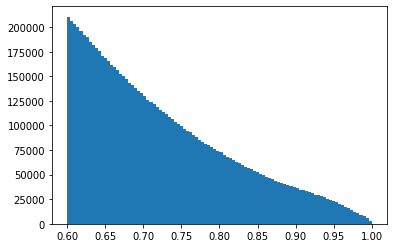

In [18]:
from matplotlib import pyplot as plt
plt.hist(corelation_list,bins=100)
plt.show()

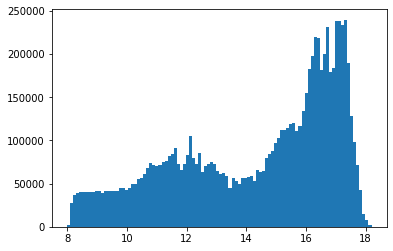

In [19]:
plt.hist(mean_list,bins=100)
plt.show()

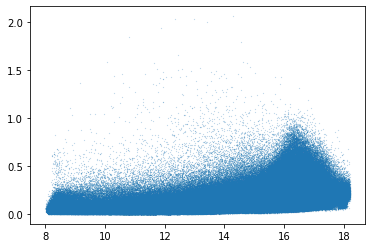

In [23]:
std_list = np.sqrt(sigma2_list)
plt.plot(mean_list,std_list,'o',ms=0.1)
plt.show()

In [74]:
flexiable_var_id_list = []
for i in range(len(var_list)):
    if best_fap_list[i]<0.05 and best_period_list[i]>345 and best_period_list[i]<385:
        continue
    elif second_fap_list[i]<0.05 and second_period_list[i]>345 and second_period_list[i]<385:
        continue
    elif ex1[i]>10 or ex2[i]>10:
        continue
    else:
        flexiable_var_id_list.append(i)
print(len(flexiable_var_id_list))


7147661


In [75]:
flexiable_var_list = var_list.iloc[flexiable_var_id_list]
print(len(flexiable_var_list)) 

7147661


In [76]:
band='w2'
sub = 8.0
upper = 17.2
flexiable_var_list.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.6_var_table_filtered.csv'%(sub,upper,band),index=False)

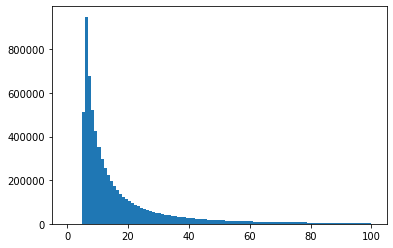

In [97]:
distances = flexiable_var_list['distance']
plt.hist(distances, bins=100,range=(0,100))   
plt.show()

In [29]:
strict_var_id_list = []
for index in flexiable_var_id_list:
    if corelation_list[index] > 0.7:
        strict_var_id_list.append(index)
print(len(strict_var_id_list))

4145147


In [41]:
strict_var_list = var_list.iloc[strict_var_id_list]
print(len(strict_var_list)) 

4145147


In [42]:
band='w1'
strict_var_list.to_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.7_var_table_new.csv'%(8.0,18.1,band),index=False)

1.1888838141930689 1.8011623365065927
10357
4.8360349 , -81.8809356 4.8360349 -81.8809356
2792.9555687731704
16.468765178195177
0.6341313503321822


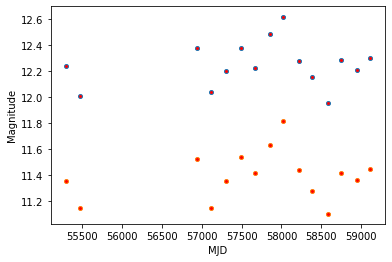

In [99]:
from util import make_single_light_curve
from IPython.display import clear_output
target_list = flexiable_var_list
i=0
while i < len(target_list):
    # if ex1[i]>10 or ex2[i]>10:
    # if i in second_period_exclude_list and i not in best_period_exclude_list:
    # if i in second_period_exclude_list:
    # if i not in best_period_exclude_list and i not in second_period_exclude_list and i not in sigma2_excluded_list:
    if i in flexiable_var_id_list:
        clear_output(wait=True)

        print(ex1[i],ex2[i])
        # ra,dec = target_list.iloc[i]['ra'],target_list.iloc[i]['dec']
        # print(ra,dec)
        long_name = target_list.iloc[i]['long_name']
        id_in_matched = target_list.iloc[i]['id_in_matched']
        # target_id = target_list.iloc[i]['TARGETID']
        id_w1 = target_list.iloc[i]['id_w1']
        id_w2 = target_list.iloc[i]['id_w2']
        distance = target_list.iloc[i]['distance']
        name = long_name[0:3]
        if distance>1000:
            table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
            table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
            ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
            ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
            # df1 = pd.DataFrame({'mag':mag1,'error':error1,'mjdmean':mjdmean1})
            # df2 = pd.DataFrame({'mag':mag2,'error':error2,'mjdmean':mjdmean2})
            # df1.to_csv('./tmp_data/w1/'+str(target_id)+'_'+str(ra)+'_'+str(dec)+'.csv',index=False)
            # df2.to_csv('./tmp_data/w2/'+str(target_id)+'_'+str(ra)+'_'+str(dec)+'.csv',index=False)
            
            print(i)
            print(ra1,',',dec1,ra2,dec2)
            print(distance)
            print(mean_list[i])
            print(corelation_list[i])
            plt.xlabel('MJD')
            plt.ylabel('Magnitude')
            plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
            plt.errorbar(mjdmean2,mag2,error2,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
            plt.show()
            # i+=1
            i += np.random.randint(1,200)
            user_input = input('Do you want to continue? (y/n)')
            if user_input == 'n':
                break
        else:
            i+=1
    else:
        i+=1
        continue

In [2]:
import numpy as np
def calculate_magnitude(flux):
    if flux <= 0:
        return np.nan
    return 22.5 - 2.5 * np.log10(flux)

def calculate_error(flux,dflux):
    mag_upper = calculate_magnitude(flux - dflux)
    mag_lower = calculate_magnitude(flux + dflux)
    dmag = (mag_upper - mag_lower) / 2
    return dmag

cal_mag_ufunc  = np.frompyfunc(calculate_magnitude,1,1)
cal_error_ufunc  = np.frompyfunc(calculate_error,2,1)

def make_single_light_curve(table, index):
    line = table.iloc[index]
    line_len = len(line)
    ra = line[0]
    dec = line[1]
    flux_unfiltered = line[3:line_len:3]
    flux = np.array(flux_unfiltered[flux_unfiltered.notnull()])
    dflux_unfiltered = line[4:line_len:3]
    dflux = np.array(dflux_unfiltered[dflux_unfiltered.notnull()])
    mjdmean_unfiltered = line[5:line_len:3]
    mjdmean = np.array(mjdmean_unfiltered[mjdmean_unfiltered.notnull()])
    assert len(flux)==len(dflux) and len(dflux)==len(mjdmean), 'light curve uncomplete!'
    mag = cal_mag_ufunc(flux)
    error = cal_error_ufunc(flux,dflux)
    return ra,dec,mag, error, mjdmean

import pandas as pd
input_table = pd.read_csv('./tempfiles/zjy_5560_untimely.csv')
input_table.columns

data_list = []
for i in range(len(input_table)):
    print(i)
    long_name = input_table.iloc[i]['long_name_1']
    name = long_name[0:3]
    id_w1 = input_table.iloc[i]['id_w1_1']
    id_w2 = input_table.iloc[i]['id_w2_1']
    table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
    table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
    ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
    ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
    data_list.append([[mag1,error1,mjdmean1],[mag2,error2,mjdmean2]])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


KeyboardInterrupt: 